In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical

In [25]:
data = pd.read_csv('dataset.csv')


X = data.drop(columns=[' Label'])
y = data[' Label']


X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(X.mean(), inplace=True)


label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [26]:

X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))


y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

In [27]:

model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], 1)),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),
    LSTM(50, activation='relu', return_sequences=False),
    Dense(50, activation='relu'),
    Dropout(0.3),
    Dense(y_train.shape[1], activation='softmax')
])


model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [59]:

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test, axis=1)

print("Accuracy:", accuracy_score(y_test_classes, y_pred_classes))
print("Classification Report:\n", classification_report(y_test_classes, y_pred_classes))
print("Confusion Matrix:\n", confusion_matrix(y_test_classes, y_pred_classes))

plt.figure(figsize=(12, 6))

Accuracy: 0.9955398250460405
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00    125870
           1       0.99      1.00      0.99     25506
           2       0.99      1.00      0.99     38895
           3       1.00      1.00      1.00     18241

    accuracy                           1.00    208512
   macro avg       0.99      1.00      1.00    208512
weighted avg       1.00      1.00      1.00    208512

Confusion Matrix:
 [[125121    250    493      6]
 [    17  25487      2      0]
 [   145      1  38749      0]
 [     4      0     12  18225]]


<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

Num GPUs Available:  1
GPU Devices:  [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Epoch 1/20
20852/20852 - 157s - loss: 0.0873 - accuracy: 0.9675 - val_loss: 0.0369 - val_accuracy: 0.9843
Epoch 2/20
20852/20852 - 155s - loss: 0.0366 - accuracy: 0.9847 - val_loss: 0.0246 - val_accuracy: 0.9889
Epoch 3/20
20852/20852 - 153s - loss: 0.0294 - accuracy: 0.9873 - val_loss: 0.0237 - val_accuracy: 0.9878
Epoch 4/20
20852/20852 - 153s - loss: 0.0264 - accuracy: 0.9884 - val_loss: 0.0216 - val_accuracy: 0.9904
Epoch 5/20
20852/20852 - 153s - loss: 0.0245 - accuracy: 0.9894 - val_loss: 0.0194 - val_accuracy: 0.9914
Epoch 6/20
20852/20852 - 153s - loss: 0.0227 - accuracy: 0.9905 - val_loss: 0.0203 - val_accuracy: 0.9923
Epoch 7/20
20852/20852 - 154s - loss: 0.0219 - accuracy: 0.9907 - val_loss: 0.0185 - val_accuracy: 0.9920
Epoch 8/20
20852/20852 - 153s - loss: 0.0211 - accuracy: 0.9912 - val_loss: 0.0171 - val_accuracy: 0.9923
Epoch 9/20
20852/20852 - 153s - loss: 0.0205 - a

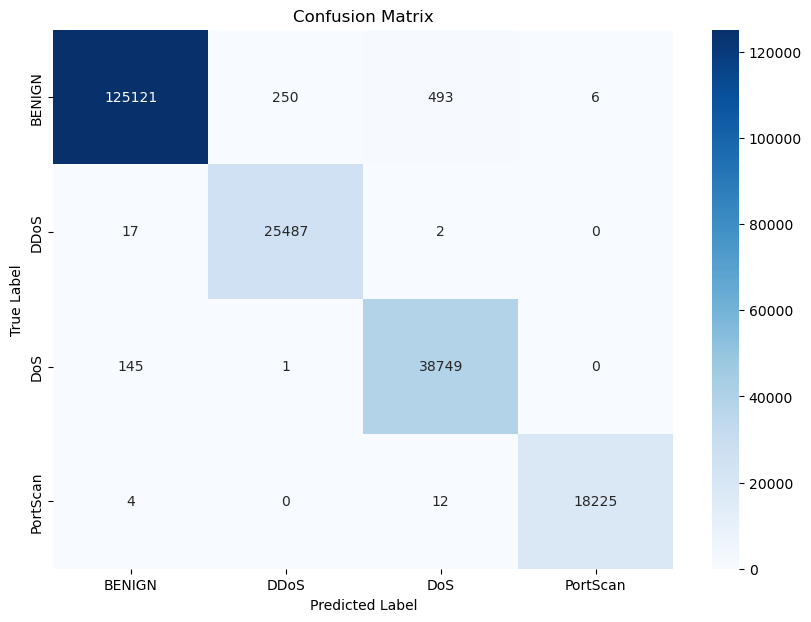

Confusion matrix saved as C:\Users\aadil\Downloads\confusion_matrix.png


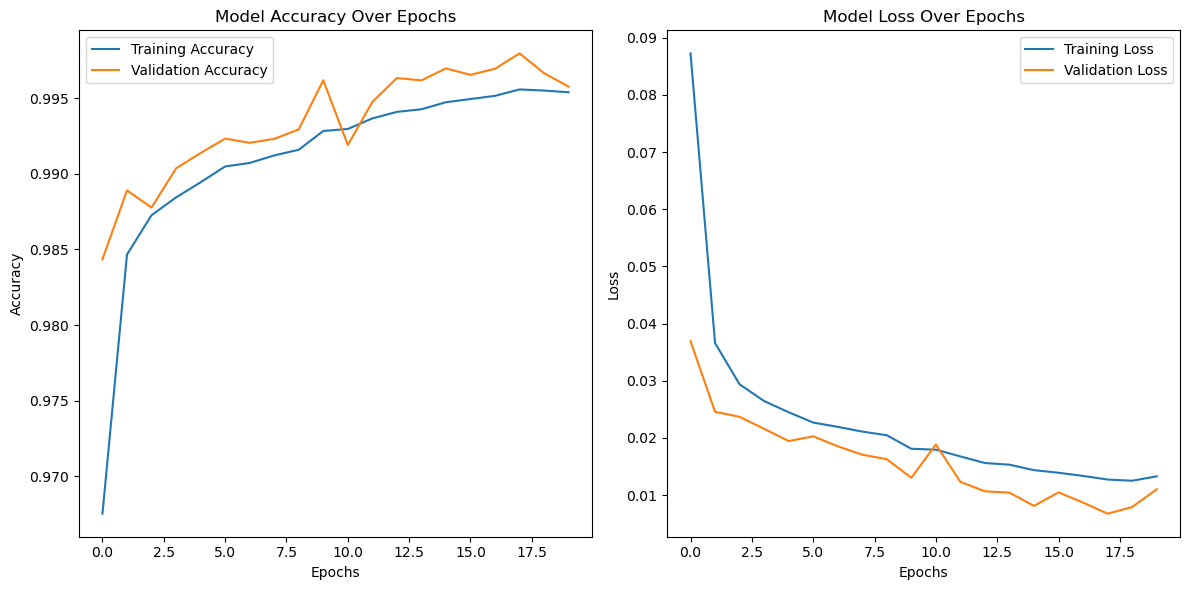

Training history plots saved as C:\Users\aadil\Downloads\training_history.png
Metrics table saved as C:\Users\aadil\Downloads\metrics_table.csv
Classification report saved as C:\Users\aadil\Downloads\classification_report.txt
Training history saved as C:\Users\aadil\Downloads\training_history.csv


In [45]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
import tensorflow as tf

# Directory to save the charts and tables
output_dir = r'C:\Users\aadil\Downloads'

# Verify if GPU is available
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print("GPU Devices: ", tf.config.list_physical_devices('GPU'))

# Load dataset
data = pd.read_csv('dataset.csv')

# Preprocess data
X = data.drop(columns=[' Label'])
y = data[' Label']
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(X.mean(), inplace=True)

# Encode labels
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype('float32')  # Ensure float32 for GPU compatibility
X_test = scaler.transform(X_test).astype('float32')

# Reshape for Conv1D input
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# One-hot encode labels
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

# Build the model
model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], 1)),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),
    LSTM(50, activation='tanh', recurrent_activation='sigmoid', return_sequences=False),
    Dense(50, activation='relu'),
    Dropout(0.3),
    Dense(y_train.shape[1], activation='softmax')
])

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2, verbose=2)

# Evaluate the model
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test, axis=1)

# Metrics
accuracy = accuracy_score(y_test_classes, y_pred_classes)
precision = precision_score(y_test_classes, y_pred_classes, average='weighted')
recall = recall_score(y_test_classes, y_pred_classes, average='weighted')
f1 = f1_score(y_test_classes, y_pred_classes, average='weighted')

# Classification report
class_report = classification_report(y_test_classes, y_pred_classes, target_names=label_encoder.classes_)
conf_matrix = confusion_matrix(y_test_classes, y_pred_classes)

# Print evaluation metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("\nClassification Report:\n", class_report)
print("\nConfusion Matrix:\n", conf_matrix)

# Save confusion matrix as a heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
conf_matrix_path = f"{output_dir}\\confusion_matrix.png"
plt.savefig(conf_matrix_path, dpi=300)
plt.show()
print(f"Confusion matrix saved as {conf_matrix_path}")

# Save training history plots
plt.figure(figsize=(12, 6))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

training_history_path = f"{output_dir}\\training_history.png"
plt.tight_layout()
plt.savefig(training_history_path, dpi=300)
plt.show()
print(f"Training history plots saved as {training_history_path}")

# Save metrics table
metrics_data = {
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Value": [accuracy, precision, recall, f1]
}
metrics_df = pd.DataFrame(metrics_data)
metrics_table_path = f"{output_dir}\\metrics_table.csv"
metrics_df.to_csv(metrics_table_path, index=False)
print(f"Metrics table saved as {metrics_table_path}")

# Save classification report
class_report_path = f"{output_dir}\\classification_report.txt"
with open(class_report_path, "w") as f:
    f.write("Classification Report:\n")
    f.write(class_report)
print(f"Classification report saved as {class_report_path}")

# Save training history as CSV
history_df = pd.DataFrame(history.history)
history_df['epoch'] = history_df.index + 1
history_csv_path = f"{output_dir}\\training_history.csv"
history_df.to_csv(history_csv_path, index=False)
print(f"Training history saved as {history_csv_path}")


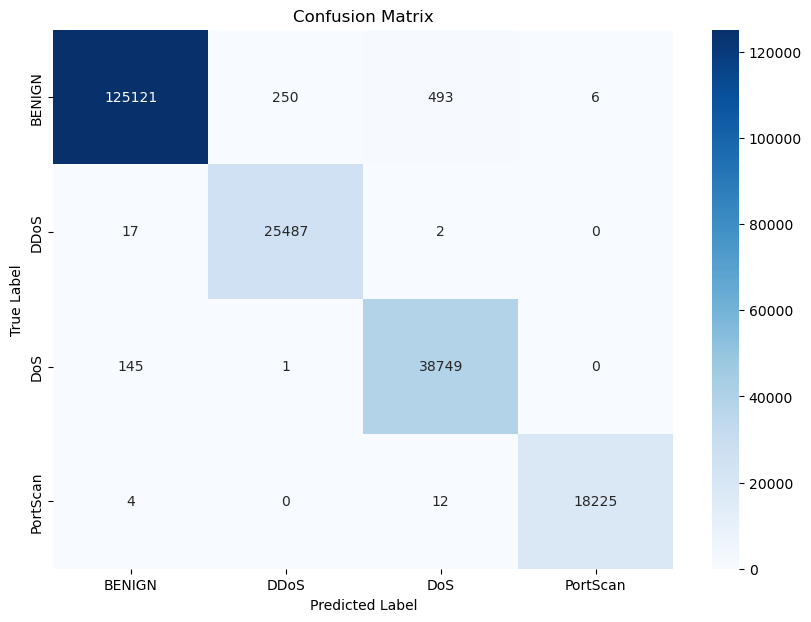

Confusion matrix saved as C:\Users\aadil\Downloads\confusion_matrix.png


In [47]:
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
conf_matrix_path = f"{output_dir}\\confusion_matrix.png"
plt.savefig(conf_matrix_path, dpi=300)
plt.show()
print(f"Confusion matrix saved as {conf_matrix_path}")

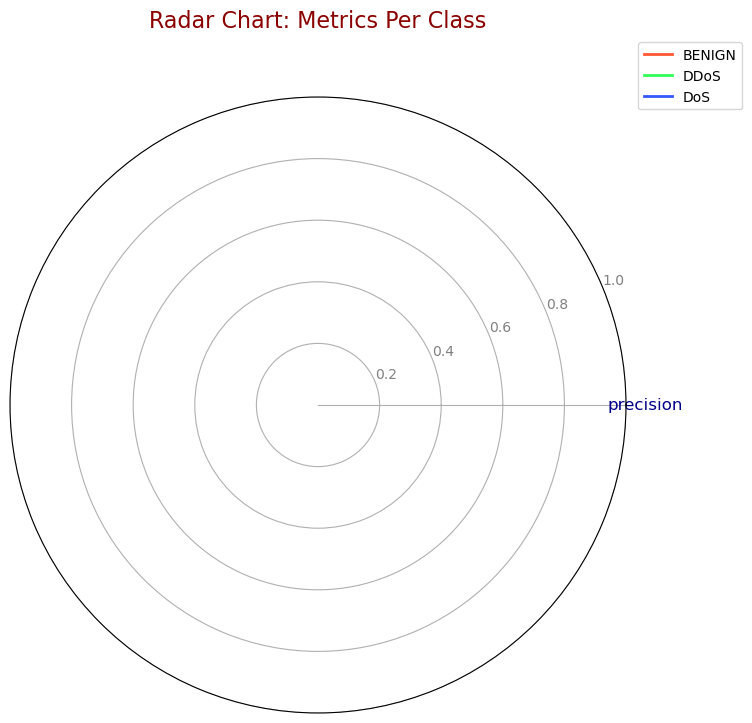

Radar chart saved as C:\Users\aadil\Downloads\radar_chart_colored.png


In [71]:
from math import pi

# Get classification report as a dictionary
class_report_dict = classification_report(
    y_test_classes, y_pred_classes, target_names=label_encoder.classes_, output_dict=True
)

# Prepare data for radar chart
metrics_df = pd.DataFrame(class_report_dict).iloc[:-3, :3]  # Exclude averages, keep precision, recall, f1-score
categories = metrics_df.index  # Class names
num_vars = len(categories)

# Prepare angles for radar chart
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # Close the loop

# Define colors for the metrics
colors = ['#FF5733', '#33FF57', '#3357FF']  # Colors for Precision, Recall, and F1-Score

# Create radar chart
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for metric, color in zip(metrics_df.columns, colors):  # Loop through precision, recall, F1-score with colors
    values = metrics_df[metric].values.flatten().tolist()
    values += values[:1]  # Close the loop for each metric
    ax.plot(angles, values, label=metric, color=color, linewidth=2)
    ax.fill(angles, values, color=color, alpha=0.25)

# Style the radar chart
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels([f"{x:.1f}" for x in [0.2, 0.4, 0.6, 0.8, 1.0]], color="gray", fontsize=10)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12, color="darkblue")
ax.set_title("Radar Chart: Metrics Per Class", size=16, y=1.1, color="darkred")
ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1), fontsize=10)

# Save radar chart
radar_chart_path = f"{output_dir}\\radar_chart_colored.png"
plt.savefig(radar_chart_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Radar chart saved as {radar_chart_path}")


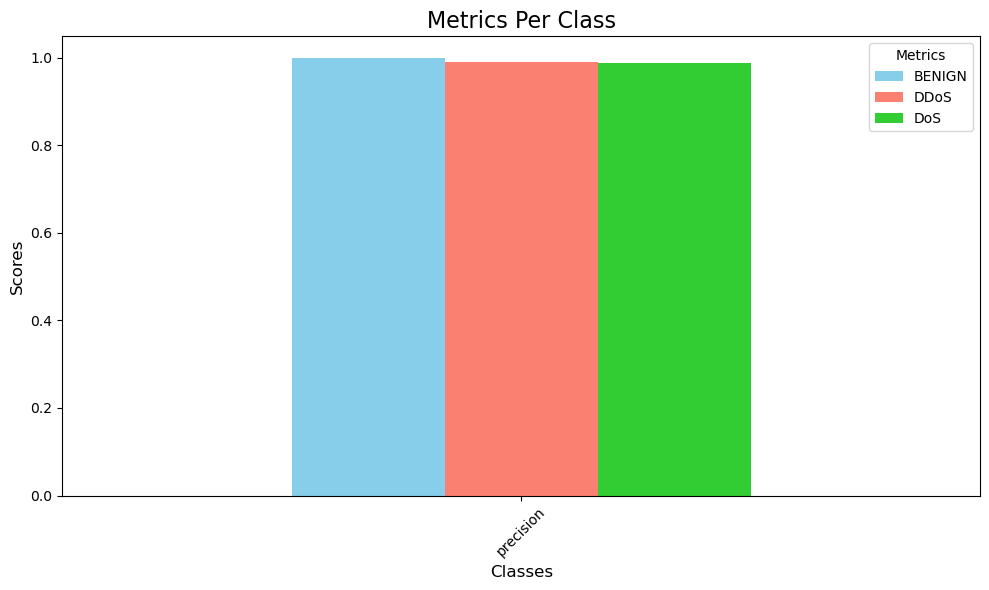

Bar chart saved as C:\Users\aadil\Downloads\metrics_bar_chart.png


In [75]:
# Get classification report as a dictionary
class_report_dict = classification_report(
    y_test_classes, y_pred_classes, target_names=label_encoder.classes_, output_dict=True
)

# Prepare data for bar chart
metrics_df = pd.DataFrame(class_report_dict).iloc[:-3, :3]  # Exclude averages, keep precision, recall, f1-score
categories = metrics_df.index  # Class names

# Plot the bar chart
metrics_df.plot(kind='bar', figsize=(10, 6), color=['skyblue', 'salmon', 'limegreen'])

# Add chart elements
plt.title("Metrics Per Class", fontsize=16)
plt.xlabel("Classes", fontsize=12)
plt.ylabel("Scores", fontsize=12)
plt.xticks(rotation=45)
plt.legend(title="Metrics")
plt.tight_layout()

# Save bar chart
bar_chart_path = f"{output_dir}\\metrics_bar_chart.png"
plt.savefig(bar_chart_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Bar chart saved as {bar_chart_path}")
